![digitizing_team](inference/digitizing_team.png)


DigiNsure Inc. is an innovative insurance company focused on enhancing the efficiency of processing claims and customer service interactions. Their newest initiative is digitizing all historical insurance claim documents, which includes improving the labeling of some IDs scanned from paper documents and identifying them as primary or secondary IDs.

To help them in their effort, you'll be using multi-modal learning to train an Optical Character Recognition (OCR) model. To improve the classification, the model will use **images** of the scanned documents as input and their **insurance type** (home, life, auto, health, or other). Integrating different data modalities (such as image and text) enables the model to perform better in complex scenarios, helping to capture more nuanced information. The **labels** that the model will be trained to identify are of two types: a primary and a secondary ID, for each image-insurance type pair.

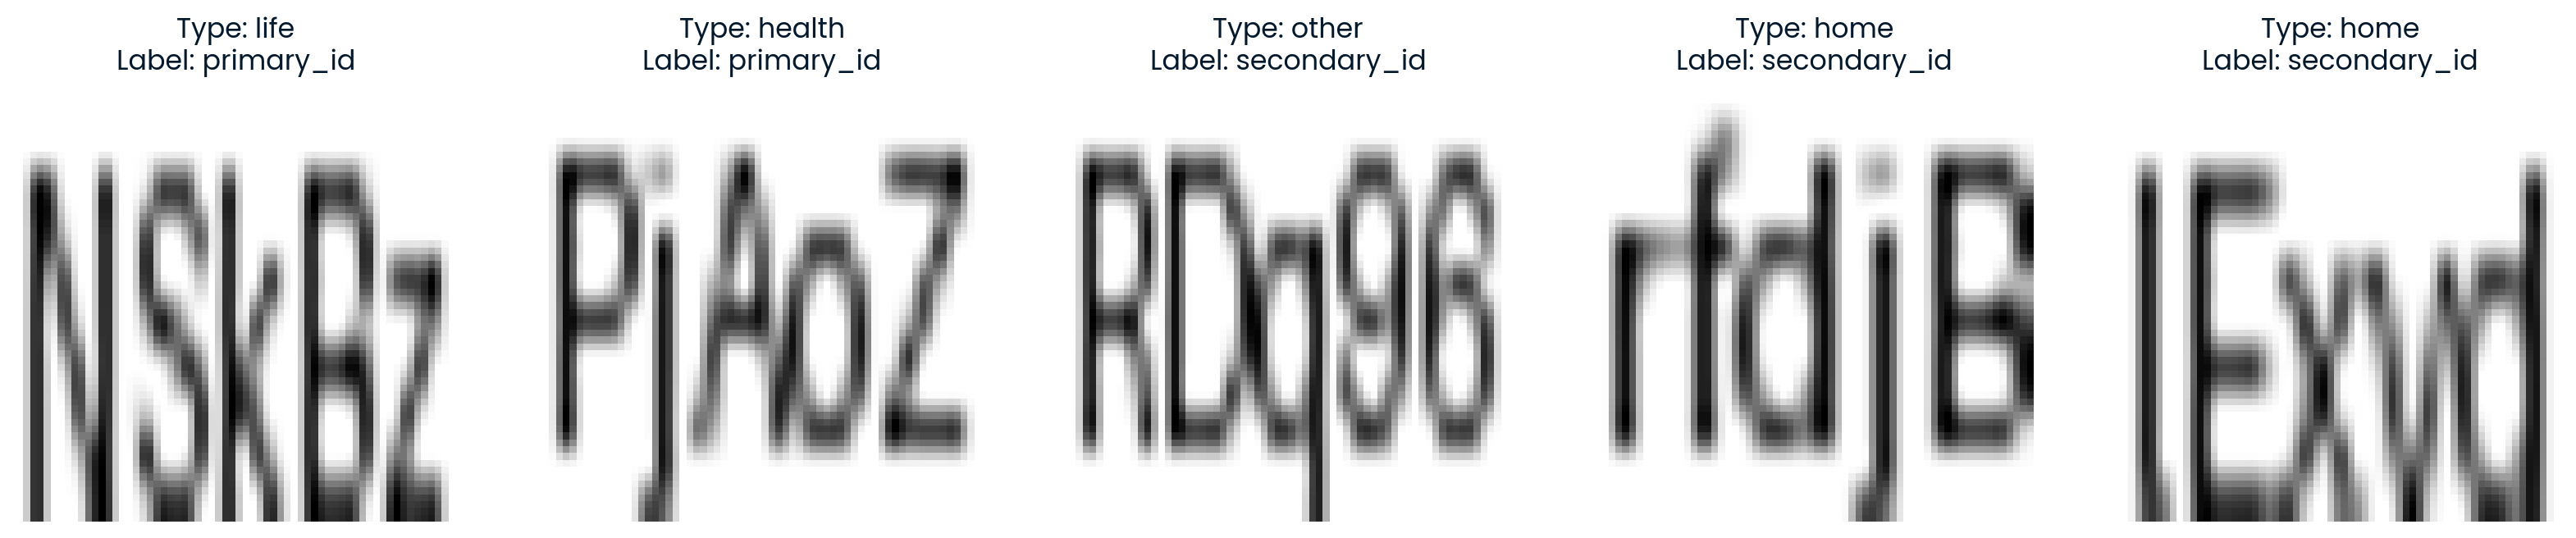

In [229]:
# Import the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from project_utils import ProjectDataset
import pickle 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Load the data
dataset = pickle.load(open('ocr_insurance_dataset.pkl', 'rb'))

# Define a function to visualize codes with their corresponding types and labels 
def show_dataset_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, min(num_images, len(dataset)), figsize=(20, 4))
    for ax, idx in zip(axes, np.random.choice(len(dataset), min(num_images, len(dataset)), False)):
        img, lbl = dataset[idx]
        ax.imshow((img[0].numpy() * 255).astype(np.uint8).reshape(64,64), cmap='gray'), ax.axis('off')
        ax.set_title(f"Type: {list(dataset.type_mapping.keys())[img[1].tolist().index(1)]}\nLabel: {list(dataset.label_mapping.keys())[list(dataset.label_mapping.values()).index(lbl)]}")
    plt.show()

# Inspect 5 codes images from the dataset
show_dataset_images(dataset)

The Network architecture

In [230]:
# Start coding here 
class OCRModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.image_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(16*32*32,128)
        )
        self.type_layer = nn.Sequential(
            nn.Linear(5,10),
            nn.ReLU()
        )

        self.classifier = nn.Linear(128+10,64)
        
    def forward(self, image, type):
        image_output = self.image_layer(image)
        type_output = self.type_layer(type)
        x = torch.cat((image_output,type_output),dim=1)
        return self.classifier(x)

loading the data

In [231]:
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

Training loop

In [232]:
import torch.optim as optim
model = OCRModel()
criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

for i in range(10):
    for (image, type), label in dataloader:
        optimizer.zero_grad()
        output = model(image,type)
        loss = criterion(output.reshape(-1,1).float(),label.float())
        loss.backward()
        optimizer.step()
    print(f'epoch {i}- loss {loss}')

epoch 0- loss 1.131678819656372
epoch 1- loss 0.5076663494110107
epoch 2- loss 0.3900821805000305
epoch 3- loss 0.3147529661655426
epoch 4- loss 0.2966500222682953
epoch 5- loss 0.2875877022743225
epoch 6- loss 0.2749859392642975
epoch 7- loss 0.2737126648426056
epoch 8- loss 0.24624457955360413
epoch 9- loss 0.2974577248096466
